In [ ]:
from pathlib import Path

OUTPUTS_ROOT = Path("/users/mbredber/p3_SUPLAT/outputs")

# ── Anchor hyperparameters (everything except f and sw) ──────────────────
RUN_GLOB_BASE = "byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw*_f*/seed2"

# Sweep axes — f=1 sw=0.05 is the anchor (exists in both rows)
F_VALS  = [0.1, 1]                      # row 1: vary f  (sw fixed at SW_ANCHOR)
SW_VALS = [0.0, 0.05, 0.1, 0.5, 1.0]   # row 2: vary sw (f  fixed at F_ANCHOR)
F_ANCHOR  = 1
SW_ANCHOR = 0.05

FEATURE_TYPE = "projections"   # "projections" or "encodings"

LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"

print("Config OK")

In [2]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
import umap as umap_lib

print("Imports OK")

Imports OK


In [3]:
# ── Label columns and tier scoring (matches rare_object_detection.ipynb) ──
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings",
           "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]
TIERS   = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2), (1, SCORE_1)]

# Initial classes (cols 0-4) + catch-all
INITIAL_NAMES = ["FRI", "FRII", "Hybrid", "Spiral", "Relaxed", "None or multiple"]

_labels_all = np.load(LABELS_NPY_PATH)   # (N_all, 20)


def build_human_labels(idx_arr: np.ndarray) -> np.ndarray:
    """Map global source indices → integer interest score 1–4."""
    ldf = pd.DataFrame(_labels_all[idx_arr].astype(bool), columns=LABEL_COLS)
    hl  = np.ones(len(ldf), dtype=int)
    for score_val, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = score_val
    return hl


def build_initial_labels(idx_arr: np.ndarray) -> np.ndarray:
    """Map global source indices → integer initial class 0–4, or 5 ('None or multiple').

    Sources with exactly one of the 5 initial labels get that class index.
    All others (unlabelled, multi-label, or non-initial) are mapped to 5.
    """
    init = _labels_all[idx_arr, 0:5].astype(bool)
    n_init = init.sum(axis=1)
    labels = np.full(len(idx_arr), 5, dtype=int)   # default: None or multiple
    for c in range(5):
        labels[(n_init == 1) & init[:, c]] = c
    return labels


def load_run(run_dir: Path, feature_type: str = "projections"):
    """Load all projections + global indices for a run (train + test).

    Handles f=0, 0<f<1, and f=1 robustly.
    Uses train_idx.npy (stable across all runs with same seed) as the
    authoritative training index list.  Shared labelled/unlabelled idx
    files are only trusted when their size matches the projection file.
    Returns (projections, idx_arr) or raises FileNotFoundError.
    """
    d = run_dir / "data"
    b = d / "byol"

    ckpt    = torch.load(run_dir / "byol_model_best.pt", map_location="cpu", weights_only=False)
    seed    = int(ckpt["config"]["data_seed"])
    f_label = float(ckpt["config"].get("f_label", 1.0))

    # Determine splits root: new layout has a seed subdir, old layout does not
    if re.match(r"seed\d+$", run_dir.name):
        s = run_dir.parent.parent.parent / "data_splits" / str(seed)
    else:
        s = run_dir.parent.parent / "data_splits" / str(seed)

    # Fraction suffix used in idx filenames (e.g. "1" or "0.1")
    f_str = str(int(f_label)) if f_label == int(f_label) else str(f_label)

    def _load_idx(name):
        p = s / name
        return np.load(p if p.exists() else d / name)

    # Stable indices — same for every run with the same seed
    train_idx_all = _load_idx("train_idx.npy")
    test_idx      = _load_idx("test_idx.npy")

    test_proj = np.load(b / f"test_{feature_type}.npy")
    lab_proj  = np.load(b / f"labelled_train_{feature_type}.npy")

    n_lab = len(lab_proj)
    n_all = len(train_idx_all)

    unlab_path = b / f"unlabelled_train_{feature_type}.npy"

    if f_label == 0.0 or n_lab == n_all:
        # f=0: train_extract_loader uses unlab_ds (all training), so lab_proj = ALL training.
        #       unlabelled_train file also exists but is identical data — skip to avoid doubling.
        # f=1: lab_proj also = ALL training, no unlabelled file.
        train_proj    = lab_proj
        train_idx_out = train_idx_all
    else:
        # Partial f (0 < f < 1): lab_proj has n_lab < n_all entries.
        # Try shared idx files (with fraction suffix); fall back to contiguous slice.
        try:
            lab_idx_shared = _load_idx(f"labelled_train_idx_f{f_str}.npy")
        except FileNotFoundError:
            lab_idx_shared = _load_idx("labelled_train_idx.npy")
        lab_idx = lab_idx_shared if len(lab_idx_shared) == n_lab else train_idx_all[:n_lab]

        if unlab_path.exists():
            unlab_proj = np.load(unlab_path)
            n_unlab = len(unlab_proj)
            try:
                unlab_idx_shared = _load_idx(f"unlabelled_train_idx_f{f_str}.npy")
            except FileNotFoundError:
                unlab_idx_shared = _load_idx("unlabelled_train_idx.npy")
            unlab_idx = (unlab_idx_shared if len(unlab_idx_shared) == n_unlab
                         else train_idx_all[n_lab:n_lab + n_unlab])
            train_proj    = np.concatenate([lab_proj, unlab_proj], axis=0)
            train_idx_out = np.concatenate([lab_idx, unlab_idx])
        else:
            train_proj    = lab_proj
            train_idx_out = lab_idx

    all_proj = np.concatenate([train_proj, test_proj], axis=0)
    all_idx  = np.concatenate([train_idx_out, test_idx])
    return all_proj, all_idx


def get_or_fit_umap(run_dir: Path, projections: np.ndarray,
                    feature_type: str = "projections") -> np.ndarray:
    """Return cached 2-D UMAP coords, or fit and cache them.

    Checks (in order):
      1. Parquet at <run_dir>/data/umap/umap_<feature_type>.parquet (from train_byol.py)
      2. .npy cache at <run_dir>/data/umap/umap_<feature_type>_coords.npy
      3. Fits UMAP and saves a .npy cache for future use.
    """
    n = projections.shape[0]
    umap_dir = run_dir / "data" / "umap"

    parquet = umap_dir / f"umap_{feature_type}.parquet"
    if parquet.exists():
        _df = pd.read_parquet(parquet, columns=["umap_x", "umap_y"])
        if len(_df) == n:
            return _df[["umap_x", "umap_y"]].values

    npy_cache = umap_dir / f"umap_{feature_type}_coords.npy"
    if npy_cache.exists():
        coords = np.load(npy_cache)
        if coords.shape[0] == n:
            return coords

    print(f"  fitting UMAP ({n} sources, dim={projections.shape[1]})...",
          flush=True)
    reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1,
                            metric="euclidean", random_state=42)
    coords = reducer.fit_transform(projections)
    umap_dir.mkdir(parents=True, exist_ok=True)
    np.save(npy_cache, coords)
    return coords


print("Helpers defined")

Helpers defined


In [4]:
# ── Discover all matching runs, keep seed2 (or latest seed) per (f, sw) ──
all_matches = sorted(OUTPUTS_ROOT.glob(RUN_GLOB_BASE))

run_map = {}   # (f, sw) -> run_dir
for rd in all_matches:
    # For seed-subdir layout the hyperparams are in the parent dir name
    name_to_parse = rd.parent.name if re.match(r"seed\d+$", rd.name) else rd.name
    # New naming: _sw{sw}_f{f}  (sw before f, no timestamp)
    m = re.search(r"_sw([\d.]+)_f([\d.]+)", name_to_parse)
    if m:
        key = (float(m.group(2)), float(m.group(1)))   # (f, sw)
    else:
        # Fall back to old naming: _f{f}_sw{sw}_timestamp
        m = re.search(r"_f([\d.]+)_sw([\d.]+)", name_to_parse)
        if not m:
            continue
        key = (float(m.group(1)), float(m.group(2)))
    run_map[key] = rd   # sorted → latest seed wins

print(f"Found {len(run_map)} unique (f, sw) combinations:")
for (f, sw), rd in sorted(run_map.items()):
    print(f"  f={f}  sw={sw}  →  {rd}")

Found 10 unique (f, sw) combinations:
  f=0.1  sw=0.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f0.1/seed2
  f=0.1  sw=0.05  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.1/seed2
  f=0.1  sw=0.1  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f0.1/seed2
  f=0.1  sw=0.5  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.5_f0.1/seed2
  f=0.1  sw=1.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw1.0_f0.1/seed2
  f=1.0  sw=0.0  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1/seed2
  f=1.0  sw=0.05  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/seed2
  f=1.0  sw=0.1  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1/seed2
  f=1.0  sw=0.5  →  /users/mbredber/p3_SUPLAT/outputs/byol_runs/pd128_qext_v1_wd1e-3

In [5]:
# ── Load projections and fit/load UMAP for every discovered run ──────────
run_data = {}   # (f, sw) -> dict(coords, human_labels, initial_labels)

for key, rd in sorted(run_map.items()):
    f, sw = key
    print(f"[f={f}  sw={sw}]  {rd.name}", flush=True)
    try:
        proj, idx = load_run(rd, FEATURE_TYPE)
        coords    = get_or_fit_umap(rd, proj, FEATURE_TYPE)
        run_data[key] = dict(
            coords         = coords,
            human_labels   = build_human_labels(idx),
            initial_labels = build_initial_labels(idx),
            run_dir        = rd,
        )
        print(f"  → {proj.shape[0]} sources, UMAP shape {coords.shape}")
    except FileNotFoundError as e:
        print(f"  ✗ skipping: {e}")

print(f"Loaded {len(run_data)} runs.")

[f=0.1  sw=0.0]  seed2


  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.05]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.1]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=0.5]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=0.1  sw=1.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.05]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.1]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=0.5]  seed2
  → 7596 sources, UMAP shape (7596, 2)
[f=1.0  sw=1.0]  seed2
  → 7596 sources, UMAP shape (7596, 2)
Loaded 10 runs.


In [10]:
# ── Dependencies for _plot_sw_panels_cropped_real ─────────────────────────────
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors as _NNR


def _find_islands(umap_real, umap_gen, eps_frac=0.04, min_samples=8):
    """Cluster real+gen UMAP points; return per-point labels and island IDs."""
    pts = np.vstack([umap_real, umap_gen])
    span = max(pts[:, 0].ptp(), pts[:, 1].ptp())
    labels_cl = DBSCAN(eps=span * eps_frac, min_samples=min_samples).fit_predict(pts)
    if (labels_cl == -1).any() and (labels_cl >= 0).any():
        ids_lab = np.unique(labels_cl[labels_cl >= 0])
        centres = np.array([pts[labels_cl == k].mean(0) for k in ids_lab])
        nn = _NNR(n_neighbors=1).fit(centres)
        _, idx = nn.kneighbors(pts[labels_cl == -1])
        labels_cl[labels_cl == -1] = ids_lab[idx.ravel()]
    uniq, cnt = np.unique(labels_cl, return_counts=True)
    continent_id = uniq[np.argmax(cnt)]
    n_real = len(umap_real)
    return (labels_cl[:n_real], labels_cl[n_real:],
            continent_id, [k for k in uniq if k != continent_id])


# Label / colour metadata — 5 initial classes (index 5 = "None or multiple")
label_names_subset = INITIAL_NAMES[:5]
n_labels           = len(label_names_subset)
class_colors       = [plt.cm.tab10(i / 10.0) for i in range(n_labels)]

# Reformat run_data into the dict structure expected by _plot_sw_panels_cropped_real:
#   _sw_data[sw_val] = {umap_real, umap_gen, real_colors}
# Uses F_ANCHOR runs; umap_gen is empty (no generative model here).
_empty_gen = np.empty((0, 2))
_sw_data   = {}
for (_f_val, _sw_val), _d in run_data.items():
    if _f_val != F_ANCHOR:
        continue
    _rc = [class_colors[_l] if _l < n_labels else (1., 1., 1., 1.)
           for _l in _d["initial_labels"]]
    _sw_data[_sw_val] = dict(umap_real=_d["coords"], umap_gen=_empty_gen, real_colors=_rc)

# Output path and filename stem
_OUT_SW = OUTPUTS_ROOT / "figures" / "umaps_plotting"
_OUT_SW.mkdir(parents=True, exist_ok=True)
_ls_str = "initial"
_stem_f = re.sub(r"_sw\*_", "_sw-sweep_", RUN_GLOB_BASE.split("/")[1]).replace("f*", f"f{F_ANCHOR}")

print(f"_sw_data sw values: {sorted(_sw_data.keys())}")
print(f"_stem_f: {_stem_f}")

_sw_data sw values: [0.0, 0.05, 0.1, 0.5, 1.0]
_stem_f: pd128_qext_v1_wd1e-3_lrconst_sw-sweep_f1


SW-sweep UMAP focal (cropped, real only): projections
Saved → /users/mbredber/p3_SUPLAT/outputs/figures/umaps_plotting/umap_sw_sweep_focal_cropped_real_pd128_qext_v1_wd1e-3_lrconst_sw-sweep_f1_initial.png


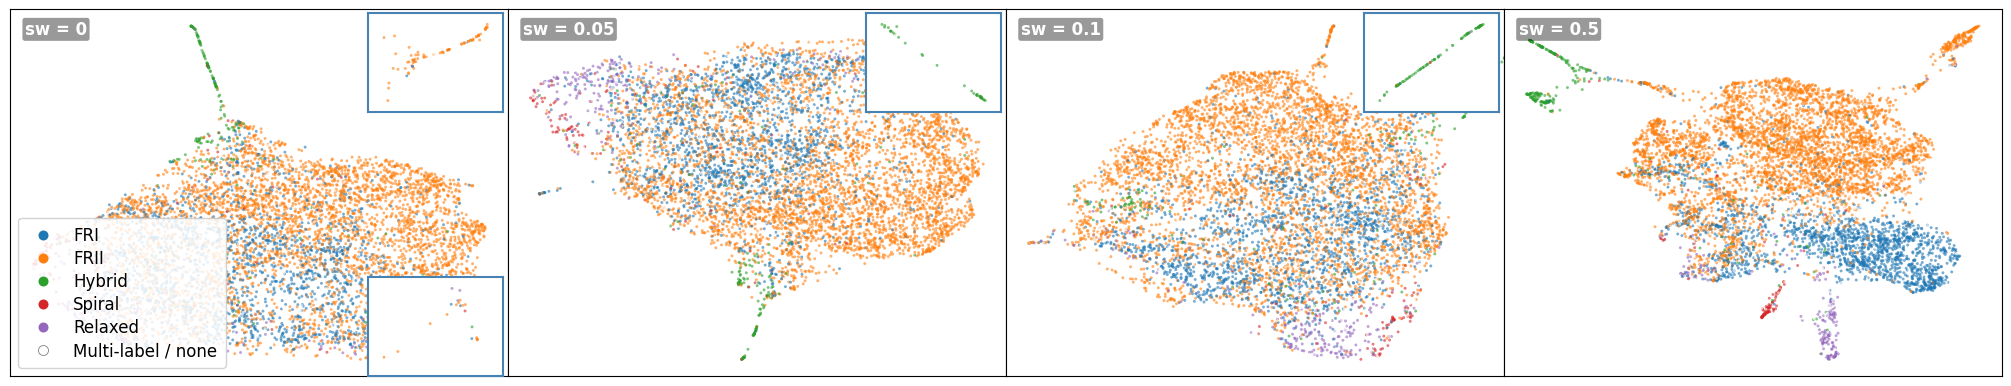

In [11]:
# ── SW-sweep UMAP — real data only (same style, no generated points) ──────────

def _plot_sw_panels_cropped_real(sw_selection, title, out_path, panel_size=3.2,
                                  legend_fontsize=10, height_ratio=0.75):
    _n = len(sw_selection)
    fig, axes = plt.subplots(1, _n, figsize=(panel_size * _n, panel_size * height_ratio),
                             gridspec_kw={"wspace": 0.0})
    if _n == 1:
        axes = [axes]
    _pt_size  = max(3, panel_size * 0.9)
    _corners = [(0.72, 0.72), (0.72, 0.00), (0.00, 0.72), (0.00, 0.00)]
    _inset_w = 0.27

    for _ax, _sw_val in zip(axes, sw_selection):
        _d = _sw_data[_sw_val]
        _ur, _ug = _d["umap_real"], _d["umap_gen"]

        # ── Island detection (same as original, using real+gen for consistent bounds) ──
        _rl, _gl, _cid, _island_ids = _find_islands(_ur, _ug)

        # Continent bounds (identical to original so axes match)
        _cont_mask_r = _rl == _cid
        _cont_mask_g = _gl == _cid
        _cont_pts = np.vstack([_ur[_cont_mask_r], _ug[_cont_mask_g]])
        _pad = lambda lo, hi, f: (lo - (hi - lo) * f, hi + (hi - lo) * f)
        _xl = _pad(_cont_pts[:, 0].min(), _cont_pts[:, 0].max(), 0.05)
        _yl = _pad(_cont_pts[:, 1].min(), _cont_pts[:, 1].max(), 0.05)
        _ax.set_xlim(_xl); _ax.set_ylim(_yl)

        # ── Real points only ──────────────────────────────────────────────────
        _ax.scatter(_ur[:, 0], _ur[:, 1],
                    c=_d["real_colors"], s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)

        _ax.text(0.03, 0.97, f"sw = {_sw_val}", transform=_ax.transAxes,
                 fontsize=12, color="white", va="top", ha="left", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.4, ec="none"))
        _ax.set_xticks([]); _ax.set_yticks([])

        # ── Island insets (up to 4) ───────────────────────────────────────────
        for _iidx, _kid in enumerate(_island_ids[:4]):
            _x0, _y0 = _corners[_iidx]
            _iax = _ax.inset_axes([_x0, _y0, _inset_w, _inset_w])

            _ir_mask = _rl == _kid
            _ig_mask = _gl == _kid
            _ipts = np.vstack([_ur[_ir_mask], _ug[_ig_mask]]) if (_ir_mask.any() or _ig_mask.any()) else None

            if _ipts is not None and len(_ipts) > 0:
                _ixl = _pad(_ipts[:, 0].min(), _ipts[:, 0].max(), 0.15)
                _iyl = _pad(_ipts[:, 1].min(), _ipts[:, 1].max(), 0.15)
                _iax.set_xlim(_ixl); _iax.set_ylim(_iyl)

            if _ir_mask.any():
                _irc = [_d["real_colors"][_j] for _j in np.where(_ir_mask)[0]]
                _iax.scatter(_ur[_ir_mask, 0], _ur[_ir_mask, 1],
                             c=_irc, s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)

            _iax.set_xticks([]); _iax.set_yticks([])
            for _spine in _iax.spines.values():
                _spine.set_edgecolor("steelblue"); _spine.set_linewidth(1.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    _ms_small = legend_fontsize * 0.6
    _class_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=class_colors[_i], markeredgecolor="none",
               markersize=_ms_small, label=label_names_subset[_i])
        for _i in range(n_labels)
    ] + [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.6,
               markersize=_ms_small, label="Multi-label / none"),
    ]
    axes[0].legend(handles=_class_handles, loc="lower left",
                   ncol=1, fontsize=legend_fontsize, framealpha=0.85,
                   borderpad=0.5, labelspacing=0.3)
    plt.tight_layout(pad=0.3)
    print(title)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()


_plot_sw_panels_cropped_real(
    [v for v in [0, 0.05, 0.1, 0.5] if v in _sw_data],
    "SW-sweep UMAP focal (cropped, real only): projections",
    _OUT_SW / f"umap_sw_sweep_focal_cropped_real_{_stem_f}_{_ls_str}.png",
    panel_size=5.0,
    legend_fontsize=12,
)